In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
P = 100000 # total population
V0 =0 # vaccinated
I0 = 1 # infected
beta =0.3
gamma =0.2
days =200

def Gillespie_model(N,I0,beta,gamma, days):

    S=N-I0
    I =I0
    R=0
    t=0

    t_=[]
    s_=[]
    i_=[]
    r_=[]
    
    while t< days and I>0:
        rate_infection = beta * S * I / P
        rate_recovery = gamma * I
        total_rate = rate_infection + rate_recovery
        dt = np.random.exponential(1 / total_rate) # events have exponential distribution
        t = t+dt
        
        infection_prob = rate_infection/total_rate
        

        if total_rate ==0:
            break

        if np.random.random() < infection_prob:
            #infection
            S =S-1  
            I =I+1
        #recovery
        else:
            I =I-1
            R =R+1
        t_.append(t)
        s_.append(S)
        i_.append(I)
        r_.append(R)

    return t_,s_,i_,r_
        

In [3]:

a,b,c,d =Gillespie_model(100000,1,0.3,0.2, 200)



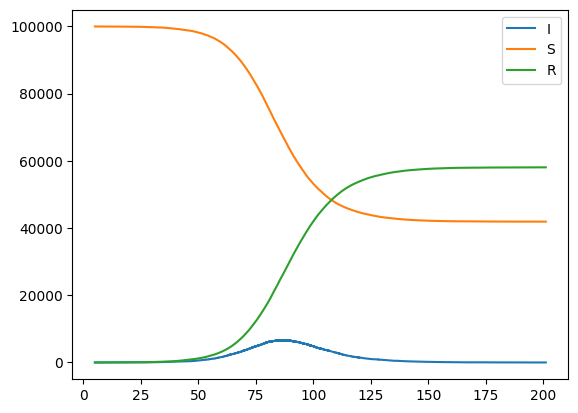

In [4]:
plt.plot(a,c,label='I')
plt.plot(a,b,label='S')
plt.plot(a,d,label='R')
plt.legend()
plt.show()

In [5]:
len(a)

116160

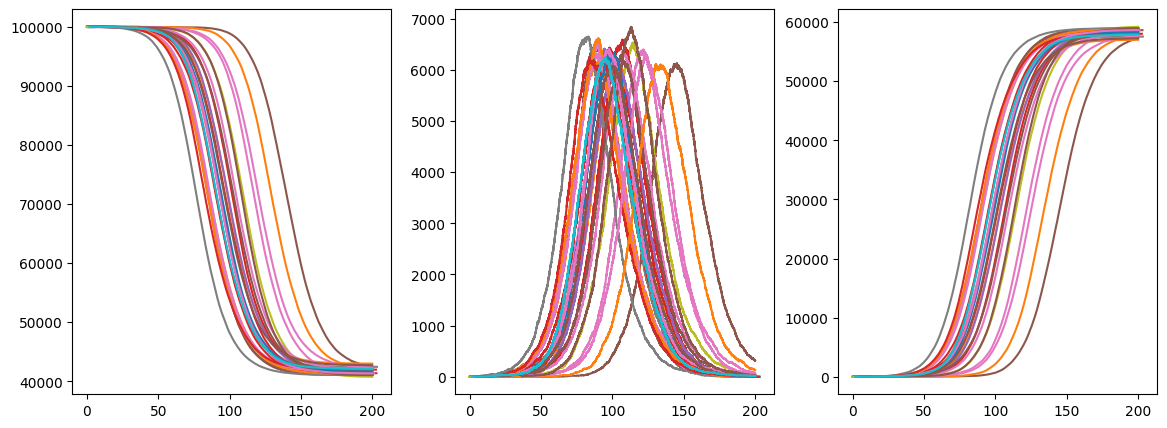

In [39]:
## repeat for 100 times


n_runs = 100
T_=[]
S_=[]
I_=[]
R_=[]

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(14, 5))
for i in range(0,n_runs):
    t_,s_,i_,r_ = Gillespie_model(100000,1,0.3,0.2, 200)
    T_.append(t_)
    S_.append(s_)
    I_.append(i_)
    R_.append(r_)
    
    ax1.plot(t_,s_,label='S')
    ax2.plot(t_,i_,label='I')
    ax3.plot(t_,r_,label='R')
 
plt.show()

